Column Data Types:
          column    dtype
0            id    int64
1       airline   object
2        flight   object
3        source   object
4     departure   object
5         stops   object
6       arrival   object
7   destination   object
8         class   object
9      duration  float64
10    days_left  float64
11        price    int64

Descriptive Statistics (min, max, mean, median):
                min        max          mean    median
id            0.00   39999.00  19999.500000  19999.50
duration      0.83      47.08     12.004088     11.08
days_left     1.00      49.00     26.197936     26.00
price      1105.00  114704.00  20801.490250   7353.00

Missing Values by Column:
              count      pct
id               0   0.0000
airline       4613  11.5325
flight           0   0.0000
source           0   0.0000
departure     4792  11.9800
stops         2319   5.7975
arrival          0   0.0000
destination      0   0.0000
class            0   0.0000
duration      3013   7.532

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


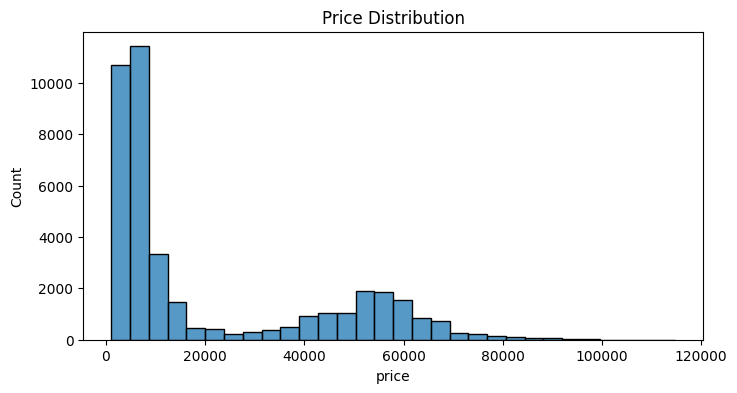

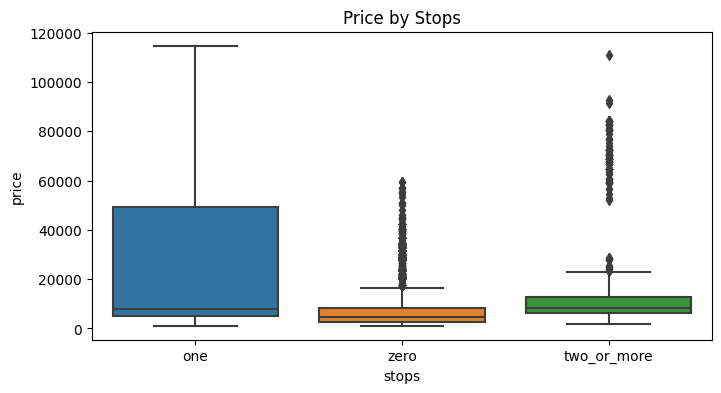

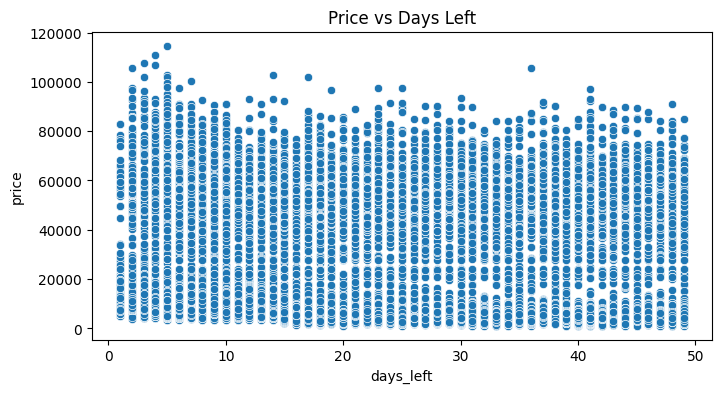


Baseline Performance:
     Model        R2         RMSE
4      RF  0.976157  3507.376505
3      DT  0.960572  4510.324453
5      GB  0.949753  5091.644499
6     MLP  0.949286  5115.265512
1   Ridge  0.921620  6359.247719
0  LinReg  0.921333  6370.869349
2   Lasso  0.920998  6384.425707
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Ridge best params: {'model__alpha': 1}
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



RF best params: {'model__n_estimators': 150, 'model__max_depth': None}
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



GB best params: {'model__n_estimators': 150, 'model__learning_rate': 0.1}

Tuned Performance:
          Model        R2         RMSE
1     RF_Tuned  0.972988  3733.230170
2     GB_Tuned  0.952672  4941.567746
0  Ridge_Tuned  0.920659  6398.106697


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Submission.csv created.


In [1]:
# 0. Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load Data
train = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv")
test = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv")

# 2. Identify Column Data Types
dtype_df = pd.DataFrame(train.dtypes, columns=['dtype']).reset_index().rename(columns={'index':'column'})
print("Column Data Types:\n", dtype_df)

# 3. Descriptive Statistics for Numerical Columns
num_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()
desc = train[num_cols].describe().T[['min','max','mean']]
medians = train[num_cols].median().to_frame('median')
stats = desc.join(medians)
print("\nDescriptive Statistics (min, max, mean, median):\n", stats)

# 4. Missing Values
missing = train.isnull().sum().to_frame('count')
missing['pct'] = missing['count'] / len(train) * 100
print("\nMissing Values by Column:\n", missing)

# 5. Duplicates
dup_count = train.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")
if dup_count > 0:
    train = train.drop_duplicates()
    print(f"Dropped duplicates, new shape: {train.shape}")

# 6. Outliers Detection (IQR)
outlier_info = {}
for col in ['duration', 'days_left', 'price']:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    count = ((train[col] < lower) | (train[col] > upper)).sum()
    outlier_info[col] = count
    print(f"Outliers in {col}: {count}")
# Decision: keep for tree-based, no capping here

# 7. Visualizations
plt.figure(figsize=(8,4))
sns.histplot(train['price'], bins=30)
plt.title('Price Distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='stops', y='price', data=train)
plt.title('Price by Stops')
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(x='days_left', y='price', data=train)
plt.title('Price vs Days Left')
plt.show()

# 8. Preprocessing with caching & sparse encoding
categorical_cols = ['airline','flight','source','departure','stops','arrival','destination','class']
numerical_cols = ['duration','days_left']

cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))  # sparse by default
])
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, categorical_cols),
    ('num', num_pipe, numerical_cols)
], sparse_threshold=0.3)

# 9. Train/Validation Split
X = train.drop(columns=['price'])
y = train['price']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 10. Define and Fit Baseline Models
# Using n_jobs=-1 for parallelism; Ridge uses solver='lsqr' to avoid sparse CG issues
models = {
    'LinReg': LinearRegression(),
    'Ridge': Ridge(random_state=42, solver='lsqr'),
    'Lasso': Lasso(random_state=42),
    'DT': DecisionTreeRegressor(random_state=42),
    'RF': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GB': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
}

# Preprocess once and cache transforms
def transform(split_X, fit=False):
    if fit:
        return preprocessor.fit_transform(split_X)
    return preprocessor.transform(split_X)

X_train_p = transform(X_train, fit=True)
X_val_p = transform(X_val)

results = []
for name, mdl in models.items():
    mdl.fit(X_train_p, y_train)
    preds = mdl.predict(X_val_p)
    results.append({'Model': name,
                    'R2': r2_score(y_val, preds),
                    'RMSE': np.sqrt(mean_squared_error(y_val, preds))})
res_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\nBaseline Performance:\n", res_df)

# 11. Hyperparameter Tuning with RandomizedSearchCV on sample
# Subsample for speed
X_samp, _, y_samp, _ = train_test_split(X_train, y_train, train_size=20000, random_state=42)

# Update Ridge instantiation in tuning models too
tune_models = {
    'Ridge': (Ridge(random_state=42, solver='lsqr'), {'alpha': [0.1,1,10]}),
    'RF': (RandomForestRegressor(random_state=42, n_jobs=-1),
           {'n_estimators':[50,100,150], 'max_depth':[None,10,20]}),
    'GB': (GradientBoostingRegressor(random_state=42),
           {'n_estimators':[100,150], 'learning_rate':[0.05,0.1]})
}

best_estimators = {}
for name, (mdl, params) in tune_models.items():
    search = RandomizedSearchCV(
        Pipeline([('pre', preprocessor),('model', mdl)]),
        param_distributions={f'model__{k}':v for k,v in params.items()},
        n_iter=10, cv=3, n_jobs=-1, random_state=42, verbose=1
    )
    search.fit(X_samp, y_samp)
    print(f"\n{name} best params: {search.best_params_}")
    best_estimators[name] = search.best_estimator_

# 12. Evaluate Tuned Models on Validation Set
tuned_results = []
for name, pipe in best_estimators.items():
    preds = pipe.predict(X_val)
    tuned_results.append({'Model': name+'_Tuned',
                          'R2': r2_score(y_val, preds),
                          'RMSE': np.sqrt(mean_squared_error(y_val, preds))})
print("\nTuned Performance:\n", pd.DataFrame(tuned_results).sort_values('R2', ascending=False))

# 13. Final Training on Full Data & Submission
# Using best RF parameters; Ridge solver fix applied
final_pipe = Pipeline([('pre', preprocessor),
                       ('model', RandomForestRegressor(
                           n_estimators=100,
                           max_depth=None,
                           random_state=42,
                           n_jobs=-1))],
                       memory='cache_dir')
final_pipe.fit(X, y)
X_test = test.drop(columns=['id'])
preds_test = final_pipe.predict(X_test)
submission = pd.DataFrame({'id': test['id'], 'price': preds_test.astype(int)})
submission.to_csv('submission.csv', index=False)
print("Submission.csv created.")
